# Hương

# Linh

Please download 5 datasets and set name as below then click Run All code

/content/user.json

/content/user-problem.json

/content/user-video.json

/content/reply.json

/content/comment.json

Chương 3: Khám phá dữ liệu

3.1 File User.json

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
import pandas as pd
import json

from google.colab import drive
drive.mount('/content/drive')

user = '/content/drive/MyDrive/Colab/user.json'

# Đọc file user.json và bỏ dòng đầu tiên
user_data = []
with open(user, 'r') as f:
    f.readline() # bỏ dòng đầu
    for line in f:
        try:
            user_data.append(json.loads(line))
        except json.JSONDecodeError as e:
            print(f"Skipping malformed line: {line.strip()} - Error: {e}")

user_df = pd.DataFrame(user_data)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#xem cấu trúc dữ liệu file user.json
user_df.head()

,id,name,gender,school,year_of_birth,course_order,enroll_time
0,U_24,王帅国,1.0,清华大学,6558.0,"[597214, 605512, 597211, 597314, 597208, 62950...","[2019-05-20 16:06:48, 2019-05-24 19:34:43, 201..."
1,U_25,王帅国,0.0,清华大学,NaN,[1903985],[2020-08-07 18:59:13]
2,U_53,于歆杰,1.0,清华大学,1973.0,"[696679, 1704639, 943255, 1729417, 682164, 177...","[2020-03-01 21:24:30, 2020-03-12 16:17:02, 202..."
3,U_54,马昱春,2.0,清华大学,NaN,"[682442, 682164, 1748240, 1778890, 1829031, 17...","[2019-10-09 02:17:49, 2019-11-08 00:49:03, 202..."
4,U_67,李小马,1.0,学堂在线,6798.0,[696679],[2019-12-20 12:06:00]


In [ ]:
# Kiểm tra kích thước dữ liệu file user
print(user_df.shape)

(3330293, 7)


In [ ]:
# Kiểm tra kiểu dữ liệu file user
user_df.info()

In [ ]:
# Thống kê mô tả file user
user_df.describe()

In [ ]:
# Kiểm tra dữ liệu thiếu
user_df.isnull().sum()

3.2 File User-problem.json

In [ ]:
import json
import pandas as pd
# Đọc file user-problem.json
problem_records = []
valid_count = 0
max_records = 1000000

with open('/content/user-problem.json', 'r') as f:
    for line in f:
        if valid_count >= max_records:
            break
        try:
            record = json.loads(line)
            problem_records.append(record)
            valid_count += 1
        except json.JSONDecodeError:
            continue

user_problem_df = pd.DataFrame(problem_records)
print(f"DataFrame Shape: {user_problem_df.shape}")
display(user_problem_df.head())

DataFrame Shape: (1000000, 7)


,log_id,problem_id,user_id,is_correct,attempts,score,submit_time
0,10000_6906522,Pm_6906522,U_10000,0,1,NaN,2020-10-27 10:11:56
1,10000_6906523,Pm_6906523,U_10000,0,1,NaN,2020-10-27 10:12:13
2,10000_6906524,Pm_6906524,U_10000,1,1,NaN,2020-10-27 10:12:28
3,10000_6906525,Pm_6906525,U_10000,0,1,NaN,2020-10-27 10:14:56
4,10000_6906526,Pm_6906526,U_10000,0,1,NaN,2020-10-27 10:15:18


In [ ]:
#Kiểm tra 5 dòng đầu của file user-problem
user_problem_df.head()

,log_id,problem_id,user_id,is_correct,attempts,score,submit_time
0,10000_6906522,Pm_6906522,U_10000,0,1,NaN,2020-10-27 10:11:56
1,10000_6906523,Pm_6906523,U_10000,0,1,NaN,2020-10-27 10:12:13
2,10000_6906524,Pm_6906524,U_10000,1,1,NaN,2020-10-27 10:12:28
3,10000_6906525,Pm_6906525,U_10000,0,1,NaN,2020-10-27 10:14:56
4,10000_6906526,Pm_6906526,U_10000,0,1,NaN,2020-10-27 10:15:18


In [ ]:
# Kiểm tra kích thước dữ liệu file problem

print(user_problem_df.shape)

(783907, 7)


In [ ]:
#Kiểm tra kiểu dữ liệu file problem
user_problem_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 7 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   log_id       1000000 non-null  object 
 1   problem_id   1000000 non-null  object 
 2   user_id      1000000 non-null  object 
 3   is_correct   1000000 non-null  int64  
 4   attempts     1000000 non-null  int64  
 5   score        520534 non-null   float64
 6   submit_time  1000000 non-null  object 
dtypes: float64(1), int64(2), object(4)
memory usage: 53.4+ MB


In [ ]:
#Thống kê mô tả file problem
user_problem_df.describe()

,is_correct,attempts,score
count,1000000.000000,1000000.000000,520534.000000
mean,0.819730,1.058975,1.511911
std,0.384412,0.700367,4.402729
min,0.000000,1.000000,-1.000000
25%,1.000000,1.000000,1.000000
50%,1.000000,1.000000,1.000000
75%,1.000000,1.000000,1.000000
max,1.000000,121.000000,50.000000


In [ ]:
#Kiểm tra dữ liệu thiếu file problem
user_problem_df.isnull().sum()

,0
log_id,0
problem_id,0
user_id,0
is_correct,0
attempts,0
score,479466
submit_time,0


3.3 File Video

In [ ]:
import json
import pandas as pd

from google.colab import drive
drive.mount('/content/drive')

userVideo = '/content/drive/MyDrive/Colab/user-video.json'
#Đọc file user-video
video_records = []
valid_count = 0
max_records = 1000000

with open(userVideo, 'r') as f:
    for line in f:
        if valid_count >= max_records:
            break

        try:
            record = json.loads(line)
            video_records.append(record)
            valid_count += 1

        except json.JSONDecodeError:
            continue

user_video_df = pd.DataFrame(video_records)

print(user_video_df.shape)
user_video_df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
(181412, 2)


,seq,user_id
0,"[{'video_id': 'V_1395633', 'segment': [{'start...",U_112
1,"[{'video_id': 'V_6224262', 'segment': [{'start...",U_150
2,"[{'video_id': 'V_6432959', 'segment': [{'start...",U_172
3,"[{'video_id': 'V_6334508', 'segment': [{'start...",U_189
4,"[{'video_id': 'V_1358540', 'segment': [{'start...",U_197


In [ ]:
# Kích thước dữ liệu user-video
print(user_video_df.shape)

(175181, 2)


In [ ]:
#Cấu trúc dữ liệu file user-video
user_video_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39992 entries, 0 to 39991
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   seq      39992 non-null  object
 1   user_id  39992 non-null  object
dtypes: object(2)
memory usage: 625.0+ KB


In [ ]:
#Thống kê mô tả user-video
user_video_df.describe()

,seq,user_id
count,39992,39992
unique,39992,39992
top,"[{'video_id': 'V_1358540', 'segment': [{'start...",U_11849008
freq,1,1


In [ ]:
#Dữ liệu bị thiếu user-video
user_video_df.isnull().sum()

,0
seq,0
user_id,0


3.4 Reply.json

In [ ]:
import json
import pandas as pd

from google.colab import drive
drive.mount('/content/drive')

reply = '/content/drive/MyDrive/Colab/reply.json'

reply_records = []
valid_count = 0
max_records = 1000000
with open(reply, 'r') as f:
    for line in f:
        if valid_count >= max_records:
            break
        try:
            record = json.loads(line)
            reply_records.append(record)
            valid_count += 1
        except json.JSONDecodeError:
            continue

reply_df = pd.DataFrame(reply_records)

print(reply_df.shape)
reply_df.head()

In [ ]:
reply_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151747 entries, 0 to 151746
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   id           151747 non-null  object
 1   user_id      151747 non-null  object
 2   text         151747 non-null  object
 3   create_time  151747 non-null  object
dtypes: object(4)
memory usage: 4.6+ MB


In [ ]:
reply_df.describe()

,id,user_id,text,create_time
count,151747,151747,151747,151747
unique,151747,30523,87607,148497
top,Rp_152040,U_3558829,回答正确，有自己的见解，继续努力。,2020-03-28 13:42:33
freq,1,6940,2574,13


In [ ]:
reply_df.isnull().sum()

,0
id,0
user_id,0
text,0
create_time,0


3.5 Comment.json

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

path = '/content/drive/MyDrive/Colab/comment.json'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import json
import pandas as pd

# Lưu dữ liệu
comment_records = []

valid_count = 0
max_records = 1000000   # 1 triệu dòng

with open(path, 'r') as f:
    for line in f:
        if valid_count >= max_records:
            break

        try:
            record = json.loads(line)
            comment_records.append(record)
            valid_count += 1

        except json.JSONDecodeError:
            continue

# Tạo DataFrame
comment_df = pd.DataFrame(comment_records)

print("Shape:", comment_df.shape)
comment_df.head()

Shape: (1000000, 5)


,id,user_id,text,resource_id,create_time
0,Cm_1,10030806,测试评论,None,2019-08-05 12:55:27
1,Cm_4,1705400,嗯嗯,None,2019-08-05 16:56:43
2,Cm_5,10031537,是的，我也看不到,None,2019-08-07 21:05:38
3,Cm_7,10031502,大师傅as,None,2019-08-09 13:06:06
4,Cm_12,10031397,点赞,None,2019-08-09 16:38:56


In [ ]:
# Kích thước
print(comment_df.shape)

# Cấu trúc
comment_df.info()

# Thống kê
comment_df.describe()

# Missing value
comment_df.isnull().sum()

(1000000, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 5 columns):
 #   Column       Non-Null Count    Dtype 
---  ------       --------------    ----- 
 0   id           1000000 non-null  object
 1   user_id      1000000 non-null  int64 
 2   text         1000000 non-null  object
 3   resource_id  262647 non-null   object
 4   create_time  1000000 non-null  object
dtypes: int64(1), object(4)
memory usage: 38.1+ MB


,0
id,0
user_id,0
text,0
resource_id,737353
create_time,0


Chương 4: Thống kê mô tả

4.1 Thống kê cơ bản

**Video**

In [ ]:
# Tạo bảng thống kê hành vi xem video của học sinh
import pandas as pd

# Hàm để trích xuất dữ liệu video và tính thời gian xem
def extract_video_data(row):
    user_id = row['user_id']
    extracted_data = []
    for video_entry in row['seq']:
        video_id = video_entry.get('video_id')
        segments = video_entry.get('segment', [])
        for segment in segments:
            start_point = segment.get('start_point', 0)
            end_point = segment.get('end_point', 0)
            watch_time = end_point - start_point
            extracted_data.append({
                'user_id': user_id,
                'video_id': video_id,
                'watch_time': watch_time
            })
    return extracted_data

# Áp dụng hàm cho từng hàng và làm phẳng danh sách các dictionary
# Sử dụng .explode() yêu cầu kết quả của apply phải là một Series chứa các list
# Vì vậy, chúng ta áp dụng hàm trước, sau đó làm phẳng danh sách các dictionary, rồi chuyển đổi thành DataFrame
all_video_data_series = user_video_df.apply(extract_video_data, axis=1)

# Lọc bỏ các list trống và sau đó làm phẳng
flat_video_data = [item for sublist in all_video_data_series if sublist for item in sublist]

video_interaction_df = pd.DataFrame(flat_video_data)

# Lọc bỏ các hàng có watch_time âm hoặc bằng 0 (ví dụ: end_point < start_point)
video_interaction_df = video_interaction_df[video_interaction_df['watch_time'] > 0]

# Bây giờ, nhóm theo user_id và tổng hợp dữ liệu
video_stats = video_interaction_df.groupby("user_id").agg(
    video_watch_count=("video_id", "count"),       # tổng số phân đoạn video đã xem
    total_watch_time=("watch_time", "sum"),        # tổng thời gian xem video
    unique_videos=("video_id", "nunique")          # số lượng video duy nhất
)

print(video_stats.shape)
video_stats.head()

(39935, 3)


,video_watch_count,total_watch_time,unique_videos
user_id,,,
U_10001181,37,2878.000,1
U_10001587,28,8180.300,4
U_1000290,16,2311.700,4
U_1000342,12,60.000,2
U_1000454,2,495.119,2


In [ ]:
#Thống kê số video xem
import numpy as np

videos = video_stats["video_watch_count"]

print("Mean:", np.mean(videos))
print("Median:", np.median(videos))
print("Std:", np.std(videos))

print("Quartiles:", np.percentile(videos,[25,50,75]))

Mean: 43.30454488543884
Median: 7.0
Std: 561.9274341676178
Quartiles: [ 2.  7. 18.]


In [ ]:
#Thống kê tổng thời gian xem video
watch_time = video_stats["total_watch_time"]

print("Mean:", np.mean(watch_time))
print("Median:", np.median(watch_time))
print("Std:", np.std(watch_time))

print("Quartiles:", np.percentile(watch_time,[25,50,75]))

Mean: 1648.3025196981982
Median: 732.0
Std: 3742.5888724649108
Quartiles: [ 202.013  732.    1855.911]


Problem

In [ ]:
# Tạo bảng thống kê hành vi làm bài tập của học sinh
user_stats = user_problem_df.groupby("user_id").agg({
    "problem_id": "count",      # số bài đã làm
    "is_correct": "mean",       # độ chính xác
    "attempts": "mean"          # số lần thử trung bình
})

# đổi tên cột cho dễ hiểu
user_stats.columns = [
    "total_problems",
    "accuracy",
    "avg_attempts"
]
print(user_stats.shape)
user_stats.head()

(9515, 3)


,total_problems,accuracy,avg_attempts
user_id,,,
U_10000,7,0.142857,1.000000
U_10000130,21,0.000000,1.666667
U_10000242,12,0.000000,1.000000
U_1000038,5,0.400000,1.000000
U_10000423,16,0.125000,1.375000


In [ ]:
#Thống kê số bài làm
import numpy as np

problems = user_stats["total_problems"]

print("Mean:", np.mean(problems))
print("Median:", np.median(problems))
print("Std:", np.std(problems))

print("Quartiles:", np.percentile(problems,[25,50,75]))

Mean: 77.23797018614351
Median: 36.0
Std: 96.63830535445022
Quartiles: [ 18.  36. 100.]


In [ ]:
# Thống kê độ chính xác làm bài tập của học sinh
accuracy = user_stats["accuracy"]

print("Mean:", np.mean(accuracy))
print("Median:", np.median(accuracy))
print("Std:", np.std(accuracy))

print("Quartiles:", np.percentile(accuracy,[25,50,75]))

Mean: 0.7160308924472496
Median: 0.8297872340425532
Std: 0.30996238669225623
Quartiles: [0.59459459 0.82978723 0.96159519]


In [ ]:
#Thống kê số lần thử trung bình
attempts = user_stats["avg_attempts"]

print("Mean:", np.mean(attempts))
print("Median:", np.median(attempts))
print("Std:", np.std(attempts))

print("Quartiles:", np.percentile(attempts,[25,50,75]))

Mean: 1.083760508203732
Median: 1.0
Std: 0.8425732952315135
Quartiles: [1. 1. 1.]


Reply

In [ ]:
reply_stats = reply_df.groupby("user_id").agg({
    "id": "count",          # tổng số reply
    "text": "nunique"       # số lượng các nội dung reply unique
})

reply_stats.columns = [
    "total_replies",
    "unique_texts"
]

print(reply_stats.shape)
reply_stats.head()

(30523, 2)


,total_replies,unique_texts
user_id,,
U_10000657,1,1
U_10000676,1,1
U_10000837,1,1
U_10001364,1,1
U_10001453,1,1


In [ ]:
import numpy as np

replies = reply_stats["total_replies"]

print("Mean:", np.mean(replies))
print("Median:", np.median(replies))
print("Std:", np.std(replies))

print("Quartiles:", np.percentile(replies,[25,50,75]))

Mean: 4.971562428332732
Median: 1.0
Std: 75.12540189860653
Quartiles: [1. 1. 2.]


**Comment**

In [ ]:
comment_stats = comment_df.groupby("user_id").agg({

    "id": "count"   # số comment

})

comment_stats.columns = ["total_comments"]

# Convert the user_id index to string and prepend 'U_'
comment_stats.index = 'U_' + comment_stats.index.astype(str)
comment_stats.index.name = 'user_id' # Ensure the index name is consistent

print(comment_stats.shape)
comment_stats.head()

#Thong ke so comment
import numpy as np

comments = comment_stats["total_comments"]

print("Mean:", np.mean(comments))
print("Median:", np.median(comments))
print("Std:", np.std(comments))

print("Quartiles:", np.percentile(comments,[25,50,75]))

(132610, 1)
Mean: 7.540909433677702
Median: 3.0
Std: 12.717991523640361
Quartiles: [1. 3. 9.]


4.2 Phân tích phân phối dữ liệu

**Video**

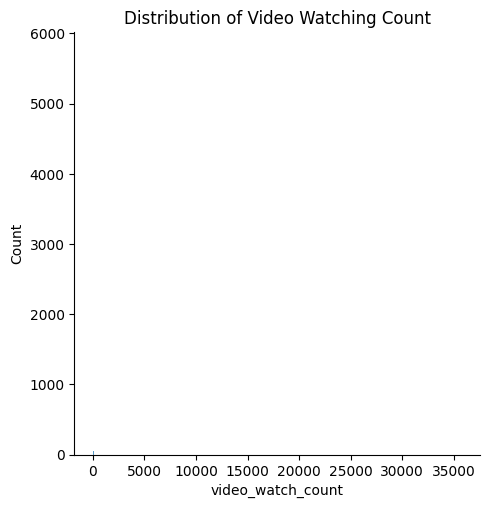

In [ ]:
#Histogram video xem
import seaborn as sns
import matplotlib.pyplot as plt

sns.displot(video_stats["video_watch_count"], kind="hist")

plt.title("Distribution of Video Watching Count")

plt.show()

In [ ]:
#KDE xem video
sns.displot(video_stats["video_watch_count"], kind="kde")

plt.title("KDE of Video Watching")

plt.show()

In [ ]:
#Rugplot
sns.displot(video_stats["video_watch_count"], kind="kde", rug=True)

plt.title("KDE with Rug Plot of Video Watching")

plt.show()

**Problem**

In [ ]:
# Histogram số bài học sinh làm
import seaborn as sns
import matplotlib.pyplot as plt

sns.displot(user_stats["total_problems"], kind="hist")

plt.title("Distribution of Problems Solved by Students")

plt.show()

In [ ]:
#Histogram độ chính xác
sns.displot(user_stats["accuracy"], kind="hist")

plt.title("Distribution of Student Accuracy")

plt.show()

In [ ]:
# KDE Mật độ dữ liệu
sns.displot(user_stats["accuracy"], kind="kde")

plt.title("KDE of Student Accuracy")

plt.show()

In [ ]:
# Rug plot
sns.displot(user_stats["accuracy"], kind="kde", rug=True)

plt.title("KDE with Rug Plot of Accuracy")

plt.show()

**Reply**

In [ ]:
sns.displot(reply_stats["total_replies"], kind="kde")

plt.title("KDE of Replies")

plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.displot(reply_stats["total_replies"], kind="hist")

plt.title("Distribution of Student Replies")

plt.show()

**Comment**

In [ ]:
#Histogram
import seaborn as sns
import matplotlib.pyplot as plt

sns.displot(comment_stats["total_comments"], kind="hist")
plt.title("Distribution of Comments")
plt.show()
#KDE
sns.displot(comment_stats["total_comments"], kind="kde")

plt.title("KDE of Comments")

plt.show()

4.3 Phát hiện Outlier

**Outlier Video**

In [ ]:
#IQR
Q1 = np.percentile(videos,25)

Q3 = np.percentile(videos,75)

IQR = Q3 - Q1

lower = Q1 - 1.5*IQR

upper = Q3 + 1.5*IQR

outliers = videos[(videos < lower) | (videos > upper)]

print("Outliers:",len(outliers))

In [ ]:
#Z-Score
from scipy.stats import zscore

z_scores = zscore(video_stats["video_watch_count"])

outliers = video_stats[abs(z_scores) > 3]

print("Outliers:", len(outliers))

In [ ]:
#Boxplot
sns.boxplot(x=video_stats["video_watch_count"])

plt.title("Outlier Detection with Boxplot")

plt.show()

**Outliers Problem**

In [ ]:
#IQR
Q1 = np.percentile(problems,25)
Q3 = np.percentile(problems,75)

IQR = Q3 - Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

outliers = problems[(problems < lower) | (problems > upper)]

print("Outliers:",len(outliers))

In [ ]:
#Z-score
from scipy.stats import zscore

z_scores = zscore(user_stats["total_problems"])

outliers = user_stats[abs(z_scores) > 3]

print("Outliers:", len(outliers))

In [ ]:
#Boxplot
sns.boxplot(x=user_stats["total_problems"])

plt.title("Outlier Detection with Boxplot")

plt.show()

**Outlier Reply**

In [ ]:
import numpy as np
# Ensure replies is defined here, in case previous cells were not run or kernel restarted
replies = reply_stats["total_replies"]

#IQR
Q1 = np.percentile(replies,25)
Q3 = np.percentile(replies,75)

IQR = Q3 - Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

outliers = replies[(replies < lower) | (replies > upper)]

print("Outliers:",len(outliers))

In [ ]:
#Z-Score
from scipy.stats import zscore

z_scores = zscore(reply_stats["total_replies"])

outliers = reply_stats[abs(z_scores) > 3]

print("Outliers:", len(outliers))

In [ ]:
#Box Plot
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(x=reply_stats["total_replies"])

plt.title("Outlier Detection (Replies)")

plt.show()

**Outliers Comment**

In [ ]:
#IQR
Q1 = np.percentile(comments,25)
Q3 = np.percentile(comments,75)

IQR = Q3 - Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

outliers = comments[(comments < lower) | (comments > upper)]

print("Outliers:",len(outliers))
#Zscore
from scipy.stats import zscore

z_scores = zscore(comment_stats["total_comments"])

outliers = comment_stats[abs(z_scores) > 3]

print("Outliers:", len(outliers))

In [ ]:
#Box Plot for Comments
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure comment_df is available (assuming it was loaded previously)
# If comment_df is also not defined, its loading cell would need to be re-executed first.
# For this fix, we assume comment_df is in the environment due to previous successful execution.

# Re-define comment_stats if it's not defined
if 'comment_stats' not in locals() and 'comment_stats' not in globals():
    # The original definition of comment_stats from cell 1KgnXOTaHREh
    comment_stats = comment_df.groupby("user_id").agg({
        "id": "count"   # số comment
    })
    comment_stats.columns = ["total_comments"]

sns.boxplot(x=comment_stats["total_comments"])

plt.title("Outlier Detection (Comments)")

plt.show()

COMBINE


### Processing `user_df` (users who registered for more than 5 courses)

In [ ]:
import pandas as pd
import json
from google.colab import drive

# Ensure user_df is defined
drive.mount('/content/drive')
user_file_path = '/content/drive/MyDrive/Colab/user.json'
user_data = []

valid_count = 0
max_records = 1000000 # Limit to 1 million records

with open(user_file_path, 'r') as f:
    f.readline() # Skip header if present, or first line as per original notebook
    for line in f:
        if valid_count >= max_records:
            break
        try:
            user_data.append(json.loads(line))
            valid_count += 1
        except json.JSONDecodeError as e:
            print(f"Skipping malformed line in user.json: {line.strip()} - Error: {e}")
user_df = pd.DataFrame(user_data)

user_df_processed = user_df.copy()
user_df_processed['num_courses'] = user_df_processed['course_order'].apply(lambda x: len(x) if isinstance(x, list) else 0)
user_df_processed = user_df_processed[user_df_processed['num_courses'] > 5]
user_df_processed = user_df_processed.rename(columns={'id': 'user_id'})

# Extract user_ids to keep for filtering other dataframes
user_ids_to_keep = set(user_df_processed['user_id'].unique())

print(f"Processed user_df shape: {user_df_processed.shape}")
display(user_df_processed.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Processed user_df shape: (129516, 8)


,user_id,name,gender,school,year_of_birth,course_order,enroll_time,num_courses
0,U_24,王帅国,1.0,清华大学,6558.0,"[597214, 605512, 597211, 597314, 597208, 62950...","[2019-05-20 16:06:48, 2019-05-24 19:34:43, 201...",65
2,U_53,于歆杰,1.0,清华大学,1973.0,"[696679, 1704639, 943255, 1729417, 682164, 177...","[2020-03-01 21:24:30, 2020-03-12 16:17:02, 202...",8
3,U_54,马昱春,2.0,清华大学,NaN,"[682442, 682164, 1748240, 1778890, 1829031, 17...","[2019-10-09 02:17:49, 2019-11-08 00:49:03, 202...",9
6,U_69,培源_,1.0,清华大学,NaN,"[375775, 375778, 584329, 584313, 597313, 59722...","[2019-02-26 19:21:24, 2019-02-28 18:12:14, 201...",18
9,U_105,吕秋亮,1.0,,NaN,"[609639, 597334, 677109, 707373, 735157, 70705...","[2019-06-04 17:03:21, 2019-08-15 16:19:54, 201...",49


### Processing `user_problem_df` (selecting top 500k problem-solving users)

In [ ]:
import pandas as pd
import json

# Set pandas option to display all columns
pd.set_option('display.max_columns', None)

# Ensure user_problem_df is defined
problem_records = []
valid_count = 0
max_records = 1000000
with open('/content/user-problem.json', 'r') as f:
    for line in f:
        if valid_count >= max_records:
            break
        try:
            record = json.loads(line)
            problem_records.append(record)
            valid_count += 1
        except json.JSONDecodeError:
            continue
user_problem_df = pd.DataFrame(problem_records)

# Filter user_problem_df by user_ids_to_keep (from user_df_processed)
if 'user_ids_to_keep' in globals():
    user_problem_df = user_problem_df[user_problem_df['user_id'].isin(user_ids_to_keep)]

# Keeping the raw user_problem_df as the processed version as per user's request to not generate stats.
user_problem_df_processed = user_problem_df # Rename for consistency with other _processed DFs

print(f"Processed user_problem_df shape: {user_problem_df_processed.shape}")
display(user_problem_df_processed.head())

Processed user_problem_df shape: (74095, 7)


,log_id,problem_id,user_id,is_correct,attempts,score,submit_time
4090,1000342_1590652,Pm_1590652,U_1000342,0,1,0.0,2020-05-03 06:49:05
4091,1000342_1590653,Pm_1590653,U_1000342,0,1,0.0,2020-05-03 06:49:18
4092,1000342_1590654,Pm_1590654,U_1000342,1,1,1.0,2020-05-03 06:49:34
4093,1000342_1590655,Pm_1590655,U_1000342,0,1,0.0,2020-05-03 06:50:09
4094,1000342_1590656,Pm_1590656,U_1000342,1,1,1.0,2020-05-03 06:50:41


### Processing `user_video_df`

In [ ]:
import pandas as pd
import json
from google.colab import drive

# Set pandas option to display all columns
pd.set_option('display.max_columns', None)

# Ensure user_video_df is defined
drive.mount('/content/drive')
userVideo_file_path = '/content/drive/MyDrive/Colab/user-video.json'

all_video_dfs = []
chunk_size = 10000  # Number of lines to read at once

with open(userVideo_file_path, 'r') as f:
    while True:
        lines = [f.readline() for _ in range(chunk_size)]
        lines = [line for line in lines if line] # Filter out empty strings if EOF is reached before chunk_size
        if not lines:
            break

        chunk_records = []
        for line in lines:
            try:
                record = json.loads(line)
                chunk_records.append(record)
            except json.JSONDecodeError:
                continue

        if chunk_records:
            all_video_dfs.append(pd.DataFrame(chunk_records))

user_video_df = pd.concat(all_video_dfs, ignore_index=True) if all_video_dfs else pd.DataFrame()

# Filter user_video_df by user_ids_to_keep (from user_df_processed)
if 'user_ids_to_keep' in globals():
    user_video_df = user_video_df[user_video_df['user_id'].isin(user_ids_to_keep)]

print(f"Raw user_video_df shape: {user_video_df.shape}")
display(user_video_df.head())

# Keeping the raw user_video_df as the processed version as per user's request to not generate stats.
user_video_df_processed = user_video_df # Rename for consistency with other _processed DFs

print(f"Processed user_video_df shape: {user_video_df_processed.shape}")
display(user_video_df_processed.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Raw user_video_df shape: (13130, 2)


,seq,user_id
0,"[{'video_id': 'V_1395633', 'segment': [{'start...",U_112
2,"[{'video_id': 'V_6432959', 'segment': [{'start...",U_172
3,"[{'video_id': 'V_6334508', 'segment': [{'start...",U_189
4,"[{'video_id': 'V_1358540', 'segment': [{'start...",U_197
6,"[{'video_id': 'V_1358540', 'segment': [{'start...",U_514


Processed user_video_df shape: (13130, 2)


,seq,user_id
0,"[{'video_id': 'V_1395633', 'segment': [{'start...",U_112
2,"[{'video_id': 'V_6432959', 'segment': [{'start...",U_172
3,"[{'video_id': 'V_6334508', 'segment': [{'start...",U_189
4,"[{'video_id': 'V_1358540', 'segment': [{'start...",U_197
6,"[{'video_id': 'V_1358540', 'segment': [{'start...",U_514


### Processing `reply_df` (selecting top 500k users by total replies)

In [ ]:
import pandas as pd
import json
from google.colab import drive

# Set pandas option to display all columns
pd.set_option('display.max_columns', None)

# Ensure reply_df is defined
drive.mount('/content/drive')
reply_file_path = '/content/drive/MyDrive/Colab/reply.json'
reply_records = []
valid_count = 0
max_records = 1000000
with open(reply_file_path, 'r') as f:
    for line in f:
        if valid_count >= max_records:
            break
        try:
            record = json.loads(line)
            reply_records.append(record)
            valid_count += 1
        except json.JSONDecodeError:
            continue
reply_df = pd.DataFrame(reply_records)

# Filter reply_df by user_ids_to_keep (from user_df_processed)
if 'user_ids_to_keep' in globals():
    reply_df = reply_df[reply_df['user_id'].isin(user_ids_to_keep)]

# Keeping the raw reply_df as the processed version as per user's request to not generate stats.
reply_df_processed = reply_df # Rename for consistency with other _processed DFs

print(f"Processed reply_df shape: {reply_df_processed.shape}")
display(reply_df_processed.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Processed reply_df shape: (49503, 4)


,id,user_id,text,create_time
11,Rp_13,U_11731,发达,2019-09-05 14:50:14
12,Rp_14,U_11731,打发,2019-09-05 14:50:18
13,Rp_15,U_11731,打发大水,2019-09-05 14:50:26
14,Rp_16,U_6875014,嗯,2019-09-06 18:40:35
24,Rp_26,U_10926748,同学的答案基本意思对了，有一点可以再说清楚一些：如何统计捕食率？即是看被抓走/缺失的个数还是...,2019-09-12 10:45:03


### Processing `comment_df` (selecting top 500k users by total comments)

In [ ]:
import pandas as pd
import json
from google.colab import drive

# Set pandas option to display all columns
pd.set_option('display.max_columns', None)

# Ensure comment_df is defined
drive.mount('/content/drive')
comment_file_path = '/content/drive/MyDrive/Colab/comment.json' # Renamed variable for clarity

all_comment_dfs = []
chunk_size = 10000  # Number of lines to read at once

with open(comment_file_path, 'r') as f:
    while True:
        lines = [f.readline() for _ in range(chunk_size)]
        lines = [line for line in lines if line] # Filter out empty strings if EOF is reached before chunk_size
        if not lines:
            break

        chunk_records = []
        for line in lines:
            try:
                record = json.loads(line)
                chunk_records.append(record)
            except json.JSONDecodeError:
                continue

        if chunk_records:
            all_comment_dfs.append(pd.DataFrame(chunk_records))

comment_df = pd.concat(all_comment_dfs, ignore_index=True) if all_comment_dfs else pd.DataFrame()

# Note: user_id in comment_df is currently int, while others are object. Need to align this for merging.
comment_df['user_id'] = 'U_' + comment_df['user_id'].astype(str)

# Filter comment_df by user_ids_to_keep (from user_df_processed)
if 'user_ids_to_keep' in globals():
    comment_df = comment_df[comment_df['user_id'].isin(user_ids_to_keep)]

# Keeping the raw comment_df as the processed version as per user's request to not generate stats.
comment_df_processed = comment_df # Rename for consistency with other _processed DFs

print(f"Processed comment_df shape: {comment_df_processed.shape}")
display(comment_df_processed.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Processed comment_df shape: (172536, 5)


,id,user_id,text,resource_id,create_time
1,Cm_4,U_1705400,嗯嗯,None,2019-08-05 16:56:43
28,Cm_61,U_105,老师好,V_13690,2019-08-15 16:25:14
31,Cm_74,U_9520252,这个评价的功能太隐蔽了,V_286363,2019-08-23 11:25:35
33,Cm_83,U_361418,评论,None,2019-09-02 15:37:18
34,Cm_88,U_6875014,测试,None,2019-09-03 10:35:27


### Merging all processed user-centric dataframes

In [ ]:
import pandas as pd

# Set pandas option to display all columns
pd.set_option('display.max_columns', None)

# The processed dataframes are expected to be defined by the preceding cells.
# They are: user_df_processed, user_problem_df_processed, user_video_df_processed, reply_df_processed, comment_df_processed

combined_df = user_df_processed.copy()

combined_df = pd.merge(combined_df, user_problem_df_processed, on='user_id', how='left')
print(f"Shape after merging user_problem_df: {combined_df.shape}")

combined_df = pd.merge(combined_df, user_video_df_processed, on='user_id', how='left')
print(f"Shape after merging user_video_df: {combined_df.shape}")

combined_df = pd.merge(combined_df, reply_df_processed, on='user_id', how='left')
print(f"Shape after merging reply_df: {combined_df.shape}")

combined_df = pd.merge(combined_df, comment_df_processed, on='user_id', how='left')
print(f"Shape after merging comment_df: {combined_df.shape}")

print("\nFinal Combined DataFrame Head:")
display(combined_df.head())

Shape after merging user_problem_df: (202905, 14)
Shape after merging user_video_df: (202905, 15)
Shape after merging reply_df: (464791, 18)


In [ ]:
import pandas as pd
import json
from google.colab import drive

# Set pandas option to display all columns for consistency
pd.set_option('display.max_columns', None)

# Re-mount drive and load user.json to ensure user_df_processed is defined
drive.mount('/content/drive', force_remount=True)
user_file_path = '/content/drive/MyDrive/Colab/user.json'
user_data = []

valid_count_user = 0
max_records_user = 1000000 # Limit to 1 million records

with open(user_file_path, 'r') as f:
    f.readline() # Skip header if present, or first line as per original notebook
    for line in f:
        if valid_count_user >= max_records_user:
            break
        try:
            user_data.append(json.loads(line))
            valid_count_user += 1
        except json.JSONDecodeError as e:
            print(f"Skipping malformed line in user.json: {line.strip()} - Error: {e}")
user_df = pd.DataFrame(user_data)

user_df_processed = user_df.copy()
user_df_processed['num_courses'] = user_df_processed['course_order'].apply(lambda x: len(x) if isinstance(x, list) else 0)
user_df_processed = user_df_processed[user_df_processed['num_courses'] > 5]
user_df_processed = user_df_processed.rename(columns={'id': 'user_id'})

# Extract user_ids to keep for filtering other dataframes
user_ids_to_keep = set(user_df_processed['user_id'].unique())

print(f"(Re)Processed user_df_processed shape: {user_df_processed.shape}")

# Re-load user-problem.json to ensure user_problem_df_processed is defined
problem_records = []
valid_count_problem = 0
max_records_problem = 1000000
with open('/content/user-problem.json', 'r') as f:
    for line in f:
        if valid_count_problem >= max_records_problem:
            break
        try:
            record = json.loads(line)
            problem_records.append(record)
            valid_count_problem += 1
        except json.JSONDecodeError:
            continue
user_problem_df = pd.DataFrame(problem_records)

# Filter user_problem_df by user_ids_to_keep
user_problem_df = user_problem_df[user_problem_df['user_id'].isin(user_ids_to_keep)]

user_problem_df_processed = user_problem_df # Rename for consistency with other _processed DFs

print(f"(Re)Processed user_problem_df_processed shape: {user_problem_df_processed.shape}")

# Merge user_df_processed and user_problem_df_processed using an outer merge
combined_df = pd.merge(
    user_df_processed,
    user_problem_df_processed,
    on='user_id',
    how='outer'
)

# Save the resulting DataFrame to a Parquet file
output_path = '/content/combined_user_problem.parquet'
combined_df.to_parquet(output_path, index=False)

print(f"Merged DataFrame saved to {output_path}")
print(f"Shape of combined_df: {combined_df.shape}")
combined_df.head()


Mounted at /content/drive
(Re)Processed user_df_processed shape: (129516, 8)
(Re)Processed user_problem_df_processed shape: (74095, 7)
Merged DataFrame saved to /content/combined_user_problem.parquet
Shape of combined_df: (202905, 14)


,user_id,name,gender,school,year_of_birth,course_order,enroll_time,num_courses,log_id,problem_id,is_correct,attempts,score,submit_time
0,U_1000129,李明东,0.0,云南民族大学,NaN,"[735210, 799796, 1925903, 1992970, 680884, 177...","[2020-09-05 17:55:11, 2020-09-05 17:57:22, 202...",7,NaN,NaN,NaN,NaN,NaN,NaN
1,U_1000342,王怀权,0.0,云南民族大学,NaN,"[883345, 696968, 696994, 697791, 948409, 696927]","[2020-02-04 12:20:33, 2020-02-04 12:22:04, 202...",6,1000342_1590652,Pm_1590652,0.0,1.0,0.0,2020-05-03 06:49:05
2,U_1000342,王怀权,0.0,云南民族大学,NaN,"[883345, 696968, 696994, 697791, 948409, 696927]","[2020-02-04 12:20:33, 2020-02-04 12:22:04, 202...",6,1000342_1590653,Pm_1590653,0.0,1.0,0.0,2020-05-03 06:49:18
3,U_1000342,王怀权,0.0,云南民族大学,NaN,"[883345, 696968, 696994, 697791, 948409, 696927]","[2020-02-04 12:20:33, 2020-02-04 12:22:04, 202...",6,1000342_1590654,Pm_1590654,1.0,1.0,1.0,2020-05-03 06:49:34
4,U_1000342,王怀权,0.0,云南民族大学,NaN,"[883345, 696968, 696994, 697791, 948409, 696927]","[2020-02-04 12:20:33, 2020-02-04 12:22:04, 202...",6,1000342_1590655,Pm_1590655,0.0,1.0,0.0,2020-05-03 06:50:09


In [ ]:
import pandas as pd
import json
from google.colab import drive

pd.set_option('display.max_columns', None)

# Mount Google Drive
drive.mount('/content/drive', force_remount=True)

# 3. Reload and process user.json to ensure user_ids_to_keep is defined
user_file_path = '/content/drive/MyDrive/Colab/user.json'
user_data = []

valid_count_user = 0
max_records_user = 1000000 # Limit to 1 million records

with open(user_file_path, 'r') as f:
    f.readline() # Skip header if present, or first line as per original notebook
    for line in f:
        if valid_count_user >= max_records_user:
            break
        try:
            user_data.append(json.loads(line))
            valid_count_user += 1
        except json.JSONDecodeError as e:
            print(f"Skipping malformed line in user.json: {line.strip()} - Error: {e}")
user_df = pd.DataFrame(user_data)

user_df_processed = user_df.copy()
user_df_processed['num_courses'] = user_df_processed['course_order'].apply(lambda x: len(x) if isinstance(x, list) else 0)
user_df_processed = user_df_processed[user_df_processed['num_courses'] > 5]
user_df_processed = user_df_processed.rename(columns={'id': 'user_id'})

# Extract user_ids to keep for filtering other dataframes
user_ids_to_keep = set(user_df_processed['user_id'].unique())

print(f"Processed user_df_processed shape: {user_df_processed.shape}")

# 4. Load the intermediate DataFrame from /content/combined_user_problem.parquet
combined_df = pd.read_parquet('/content/combined_user_problem.parquet')
print(f"Loaded combined_user_problem.parquet shape: {combined_df.shape}")

Mounted at /content/drive
Processed user_df_processed shape: (129516, 8)
Loaded combined_user_problem.parquet shape: (202905, 14)


In [ ]:
import pandas as pd
import json
from google.colab import drive

pd.set_option('display.max_columns', None)

# Mount Google Drive
drive.mount('/content/drive', force_remount=True)

# 3. Reload and process user.json to ensure user_ids_to_keep is defined
user_file_path = '/content/drive/MyDrive/Colab/user.json'
user_data = []

valid_count_user = 0
max_records_user = 1000000 # Limit to 1 million records

with open(user_file_path, 'r') as f:
    f.readline() # Skip header if present, or first line as per original notebook
    for line in f:
        if valid_count_user >= max_records_user:
            break
        try:
            user_data.append(json.loads(line))
            valid_count_user += 1
        except json.JSONDecodeError as e:
            print(f"Skipping malformed line in user.json: {line.strip()} - Error: {e}")
user_df = pd.DataFrame(user_data)

user_df_processed = user_df.copy()
user_df_processed['num_courses'] = user_df_processed['course_order'].apply(lambda x: len(x) if isinstance(x, list) else 0)
user_df_processed = user_df_processed[user_df_processed['num_courses'] > 5]
user_df_processed = user_df_processed.rename(columns={'id': 'user_id'})

# Extract user_ids to keep for filtering other dataframes
user_ids_to_keep = set(user_df_processed['user_id'].unique())

print(f"Processed user_df_processed shape: {user_df_processed.shape}")

# 4. Load the intermediate DataFrame from /content/combined_user_problem.parquet
combined_df = pd.read_parquet('/content/combined_user_problem.parquet')
print(f"Loaded combined_user_problem.parquet shape: {combined_df.shape}")

# 5. Reload and process user-video.json in chunks
userVideo_file_path = '/content/drive/MyDrive/Colab/user-video.json'

all_video_dfs = []
chunk_size = 10000  # Number of lines to read at once

with open(userVideo_file_path, 'r') as f:
    while True:
        lines = [f.readline() for _ in range(chunk_size)]
        lines = [line for line in lines if line] # Filter out empty strings if EOF is reached before chunk_size
        if not lines:
            break

        chunk_records = []
        for line in lines:
            try:
                record = json.loads(line)
                chunk_records.append(record)
            except json.JSONDecodeError:
                continue

        if chunk_records:
            all_video_dfs.append(pd.DataFrame(chunk_records))

user_video_df = pd.concat(all_video_dfs, ignore_index=True) if all_video_dfs else pd.DataFrame()
print(f"Raw user_video_df shape: {user_video_df.shape}")

# 6. Filter user_video_df by user_ids_to_keep
user_video_df_filtered = user_video_df[user_video_df['user_id'].isin(user_ids_to_keep)]
print(f"Filtered user_video_df shape: {user_video_df_filtered.shape}")

# 7. Merge combined_df with the filtered user_video_df
combined_df = pd.merge(
    combined_df,
    user_video_df_filtered,
    on='user_id',
    how='outer' # Keep all users from combined_df
)

# 8. Save the newly merged DataFrame to /content/combined_user_problem_video.parquet
output_path_video = '/content/combined_user_problem_video.parquet'
combined_df.to_parquet(output_path_video, index=False)

print(f"Merged DataFrame saved to {output_path_video}")
print(f"Shape of final combined_df: {combined_df.shape}")

# 9. Display its head
display(combined_df.head())

Mounted at /content/drive
Processed user_df_processed shape: (129516, 8)
Loaded combined_user_problem.parquet shape: (202905, 14)
Raw user_video_df shape: (181412, 2)
Filtered user_video_df shape: (13130, 2)
Merged DataFrame saved to /content/combined_user_problem_video.parquet
Shape of final combined_df: (202905, 15)


,user_id,name,gender,school,year_of_birth,course_order,enroll_time,num_courses,log_id,problem_id,is_correct,attempts,score,submit_time,seq
0,U_1000129,李明东,0.0,云南民族大学,NaN,"[735210, 799796, 1925903, 1992970, 680884, 177...","[2020-09-05 17:55:11, 2020-09-05 17:57:22, 202...",7,None,None,NaN,NaN,NaN,None,NaN
1,U_1000342,王怀权,0.0,云南民族大学,NaN,"[883345, 696968, 696994, 697791, 948409, 696927]","[2020-02-04 12:20:33, 2020-02-04 12:22:04, 202...",6,1000342_1590652,Pm_1590652,0.0,1.0,0.0,2020-05-03 06:49:05,"[{'video_id': 'V_1358562', 'segment': [{'start..."
2,U_1000342,王怀权,0.0,云南民族大学,NaN,"[883345, 696968, 696994, 697791, 948409, 696927]","[2020-02-04 12:20:33, 2020-02-04 12:22:04, 202...",6,1000342_1590653,Pm_1590653,0.0,1.0,0.0,2020-05-03 06:49:18,"[{'video_id': 'V_1358562', 'segment': [{'start..."
3,U_1000342,王怀权,0.0,云南民族大学,NaN,"[883345, 696968, 696994, 697791, 948409, 696927]","[2020-02-04 12:20:33, 2020-02-04 12:22:04, 202...",6,1000342_1590654,Pm_1590654,1.0,1.0,1.0,2020-05-03 06:49:34,"[{'video_id': 'V_1358562', 'segment': [{'start..."
4,U_1000342,王怀权,0.0,云南民族大学,NaN,"[883345, 696968, 696994, 697791, 948409, 696927]","[2020-02-04 12:20:33, 2020-02-04 12:22:04, 202...",6,1000342_1590655,Pm_1590655,0.0,1.0,0.0,2020-05-03 06:50:09,"[{'video_id': 'V_1358562', 'segment': [{'start..."


In [ ]:
import pandas as pd
import json
from google.colab import drive

pd.set_option('display.max_columns', None)

# Mount Google Drive
drive.mount('/content/drive', force_remount=True)

# 1. Reload and process user.json to ensure user_ids_to_keep is defined
user_file_path = '/content/drive/MyDrive/Colab/user.json'
user_data = []

valid_count_user = 0
max_records_user = 1000000 # Limit to 1 million records

with open(user_file_path, 'r') as f:
    f.readline() # Skip header if present, or first line as per original notebook
    for line in f:
        if valid_count_user >= max_records_user:
            break
        try:
            user_data.append(json.loads(line))
            valid_count_user += 1
        except json.JSONDecodeError as e:
            print(f"Skipping malformed line in user.json: {line.strip()} - Error: {e}")
user_df = pd.DataFrame(user_data)

user_df_processed = user_df.copy()
user_df_processed['num_courses'] = user_df_processed['course_order'].apply(lambda x: len(x) if isinstance(x, list) else 0)
user_df_processed = user_df_processed[user_df_processed['num_courses'] > 5]
user_df_processed = user_df_processed.rename(columns={'id': 'user_id'})

# Extract user_ids to keep for filtering other dataframes
user_ids_to_keep = set(user_df_processed['user_id'].unique())

print(f"Processed user_df_processed shape for user_ids_to_keep: {user_df_processed.shape}")

# 2. Load the intermediate DataFrame from /content/combined_user_problem_video.parquet
combined_df = pd.read_parquet('/content/combined_user_problem_video.parquet')
print(f"Loaded combined_user_problem_video.parquet shape: {combined_df.shape}")

# 3. Reload reply.json
reply_file_path = '/content/drive/MyDrive/Colab/reply.json'
reply_records = []
valid_count_reply = 0
max_records_reply = 1000000
with open(reply_file_path, 'r') as f:
    for line in f:
        if valid_count_reply >= max_records_reply:
            break
        try:
            record = json.loads(line)
            reply_records.append(record)
            valid_count_reply += 1
        except json.JSONDecodeError:
            continue
reply_df = pd.DataFrame(reply_records)
print(f"Raw reply_df shape: {reply_df.shape}")

# 4. Filter reply_df by user_ids_to_keep
reply_df_filtered = reply_df[reply_df['user_id'].isin(user_ids_to_keep)]
print(f"Filtered reply_df shape: {reply_df_filtered.shape}")

# 5. Merge combined_df with the filtered reply_df
combined_df = pd.merge(
    combined_df,
    reply_df_filtered,
    on='user_id',
    how='outer' # Keep all users from combined_df
)

# 6. Save the newly merged DataFrame to /content/combined_user_problem_video_reply.parquet
output_path_reply = '/content/combined_user_problem_video_reply.parquet'
combined_df.to_parquet(output_path_reply, index=False)

print(f"Merged DataFrame saved to {output_path_reply}")
print(f"Shape of final combined_df: {combined_df.shape}")

# 7. Display its head
display(combined_df.head())

Mounted at /content/drive
Processed user_df_processed shape for user_ids_to_keep: (129516, 8)
Loaded combined_user_problem_video.parquet shape: (202905, 15)
Raw reply_df shape: (331011, 4)
Filtered reply_df shape: (49503, 4)
Merged DataFrame saved to /content/combined_user_problem_video_reply.parquet
Shape of final combined_df: (464791, 18)


,user_id,name,gender,school,year_of_birth,course_order,enroll_time,num_courses,log_id,problem_id,is_correct,attempts,score,submit_time,seq,id,text,create_time
0,U_1000129,李明东,0.0,云南民族大学,NaN,"[735210, 799796, 1925903, 1992970, 680884, 177...","[2020-09-05 17:55:11, 2020-09-05 17:57:22, 202...",7,None,None,NaN,NaN,NaN,None,None,NaN,NaN,NaN
1,U_1000342,王怀权,0.0,云南民族大学,NaN,"[883345, 696968, 696994, 697791, 948409, 696927]","[2020-02-04 12:20:33, 2020-02-04 12:22:04, 202...",6,1000342_1590652,Pm_1590652,0.0,1.0,0.0,2020-05-03 06:49:05,"[{'segment': [{'end_point': 590.0, 'local_star...",NaN,NaN,NaN
2,U_1000342,王怀权,0.0,云南民族大学,NaN,"[883345, 696968, 696994, 697791, 948409, 696927]","[2020-02-04 12:20:33, 2020-02-04 12:22:04, 202...",6,1000342_1590653,Pm_1590653,0.0,1.0,0.0,2020-05-03 06:49:18,"[{'segment': [{'end_point': 590.0, 'local_star...",NaN,NaN,NaN
3,U_1000342,王怀权,0.0,云南民族大学,NaN,"[883345, 696968, 696994, 697791, 948409, 696927]","[2020-02-04 12:20:33, 2020-02-04 12:22:04, 202...",6,1000342_1590654,Pm_1590654,1.0,1.0,1.0,2020-05-03 06:49:34,"[{'segment': [{'end_point': 590.0, 'local_star...",NaN,NaN,NaN
4,U_1000342,王怀权,0.0,云南民族大学,NaN,"[883345, 696968, 696994, 697791, 948409, 696927]","[2020-02-04 12:20:33, 2020-02-04 12:22:04, 202...",6,1000342_1590655,Pm_1590655,0.0,1.0,0.0,2020-05-03 06:50:09,"[{'segment': [{'end_point': 590.0, 'local_star...",NaN,NaN,NaN


In [ ]:
import pandas as pd
import json
from google.colab import drive

pd.set_option('display.max_columns', None)

# Mount Google Drive
drive.mount('/content/drive', force_remount=True)

# 1. Reload and process user.json to ensure user_ids_to_keep is defined
user_file_path = '/content/drive/MyDrive/Colab/user.json'
user_data = []

valid_count_user = 0
max_records_user = 1000000 # Limit to 1 million records

with open(user_file_path, 'r') as f:
    f.readline() # Skip header if present, or first line as per original notebook
    for line in f:
        if valid_count_user >= max_records_user:
            break
        try:
            user_data.append(json.loads(line))
            valid_count_user += 1
        except json.JSONDecodeError as e:
            print(f"Skipping malformed line in user.json: {line.strip()} - Error: {e}")
user_df = pd.DataFrame(user_data)

user_df_processed = user_df.copy()
user_df_processed['num_courses'] = user_df_processed['course_order'].apply(lambda x: len(x) if isinstance(x, list) else 0)
user_df_processed = user_df_processed[user_df_processed['num_courses'] > 5]
user_df_processed = user_df_processed.rename(columns={'id': 'user_id'})

# Extract user_ids to keep for filtering other dataframes
user_ids_to_keep = set(user_df_processed['user_id'].unique())

print(f"Processed user_df_processed shape for user_ids_to_keep: {user_df_processed.shape}")

# The subsequent steps in this cell are part of the original notebook's combine section
# 2. Load the intermediate DataFrame from /content/combined_user_problem_video.parquet
combined_df = pd.read_parquet('/content/combined_user_problem_video.parquet')
print(f"Loaded combined_user_problem_video.parquet shape: {combined_df.shape}")

# 3. Reload reply.json
reply_file_path = '/content/drive/MyDrive/Colab/reply.json'
reply_records = []
valid_count_reply = 0
max_records_reply = 1000000
with open(reply_file_path, 'r') as f:
    for line in f:
        if valid_count_reply >= max_records_reply:
            break
        try:
            record = json.loads(line)
            reply_records.append(record)
            valid_count_reply += 1
        except json.JSONDecodeError:
            continue
reply_df = pd.DataFrame(reply_records)
print(f"Raw reply_df shape: {reply_df.shape}")

# 4. Filter reply_df by user_ids_to_keep
reply_df_filtered = reply_df[reply_df['user_id'].isin(user_ids_to_keep)]
print(f"Filtered reply_df shape: {reply_df_filtered.shape}")

# 5. Merge combined_df with the filtered reply_df
combined_df = pd.merge(
    combined_df,
    reply_df_filtered,
    on='user_id',
    how='outer' # Keep all users from combined_df
)

# 6. Save the newly merged DataFrame to /content/combined_user_problem_video_reply.parquet
output_path_reply = '/content/combined_user_problem_video_reply.parquet'
combined_df.to_parquet(output_path_reply, index=False)

print(f"Merged DataFrame saved to {output_path_reply}")
print(f"Shape of final combined_df: {combined_df.shape}")

# 7. Display its head
display(combined_df.head())


Mounted at /content/drive
Processed user_df_processed shape for user_ids_to_keep: (129516, 8)
Loaded combined_user_problem_video.parquet shape: (202905, 15)
Raw reply_df shape: (331011, 4)
Filtered reply_df shape: (49503, 4)
Merged DataFrame saved to /content/combined_user_problem_video_reply.parquet
Shape of final combined_df: (464791, 18)


,user_id,name,gender,school,year_of_birth,course_order,enroll_time,num_courses,log_id,problem_id,is_correct,attempts,score,submit_time,seq,id,text,create_time
0,U_1000129,李明东,0.0,云南民族大学,NaN,"[735210, 799796, 1925903, 1992970, 680884, 177...","[2020-09-05 17:55:11, 2020-09-05 17:57:22, 202...",7,None,None,NaN,NaN,NaN,None,None,NaN,NaN,NaN
1,U_1000342,王怀权,0.0,云南民族大学,NaN,"[883345, 696968, 696994, 697791, 948409, 696927]","[2020-02-04 12:20:33, 2020-02-04 12:22:04, 202...",6,1000342_1590652,Pm_1590652,0.0,1.0,0.0,2020-05-03 06:49:05,"[{'segment': [{'end_point': 590.0, 'local_star...",NaN,NaN,NaN
2,U_1000342,王怀权,0.0,云南民族大学,NaN,"[883345, 696968, 696994, 697791, 948409, 696927]","[2020-02-04 12:20:33, 2020-02-04 12:22:04, 202...",6,1000342_1590653,Pm_1590653,0.0,1.0,0.0,2020-05-03 06:49:18,"[{'segment': [{'end_point': 590.0, 'local_star...",NaN,NaN,NaN
3,U_1000342,王怀权,0.0,云南民族大学,NaN,"[883345, 696968, 696994, 697791, 948409, 696927]","[2020-02-04 12:20:33, 2020-02-04 12:22:04, 202...",6,1000342_1590654,Pm_1590654,1.0,1.0,1.0,2020-05-03 06:49:34,"[{'segment': [{'end_point': 590.0, 'local_star...",NaN,NaN,NaN
4,U_1000342,王怀权,0.0,云南民族大学,NaN,"[883345, 696968, 696994, 697791, 948409, 696927]","[2020-02-04 12:20:33, 2020-02-04 12:22:04, 202...",6,1000342_1590655,Pm_1590655,0.0,1.0,0.0,2020-05-03 06:50:09,"[{'segment': [{'end_point': 590.0, 'local_star...",NaN,NaN,NaN


In [ ]:
import pandas as pd
import json
from google.colab import drive

# Mount Google Drive (Step 1 - if not already mounted)
drive.mount('/content/drive', force_remount=True)

# 2. Define the path to user.json
user_file_path = '/content/drive/MyDrive/Colab/user.json'

# 3. Initialize an empty list to store parsed user records
user_data = []

valid_count_user = 0
max_records_user = 1000000 # Limit to 1 million records

# 4. Open and read user.json, skipping the first line and limiting records
with open(user_file_path, 'r') as f:
    f.readline() # Skip the first line
    for line in f:
        if valid_count_user >= max_records_user:
            break
        try:
            user_data.append(json.loads(line))
            valid_count_user += 1
        except json.JSONDecodeError as e:
            print(f"Skipping malformed line in user.json: {line.strip()} - Error: {e}")

# 5. Create a pandas DataFrame from user_data
user_df = pd.DataFrame(user_data)

# 6. Create a copy for processing
user_df_processed = user_df.copy()

# 7. Add num_courses column
user_df_processed['num_courses'] = user_df_processed['course_order'].apply(lambda x: len(x) if isinstance(x, list) else 0)

# 8. Filter to include only users where num_courses > 5
user_df_processed = user_df_processed[user_df_processed['num_courses'] > 5]

# 9. Rename the 'id' column to 'user_id'
user_df_processed = user_df_processed.rename(columns={'id': 'user_id'})

# 10. Create user_ids_to_keep set
user_ids_to_keep = set(user_df_processed['user_id'].unique())

# 11. Print the shape and display its first few rows
print(f"Processed user_df_processed shape: {user_df_processed.shape}")
display(user_df_processed.head())

Mounted at /content/drive
Processed user_df_processed shape: (129516, 8)


,user_id,name,gender,school,year_of_birth,course_order,enroll_time,num_courses
0,U_24,王帅国,1.0,清华大学,6558.0,"[597214, 605512, 597211, 597314, 597208, 62950...","[2019-05-20 16:06:48, 2019-05-24 19:34:43, 201...",65
2,U_53,于歆杰,1.0,清华大学,1973.0,"[696679, 1704639, 943255, 1729417, 682164, 177...","[2020-03-01 21:24:30, 2020-03-12 16:17:02, 202...",8
3,U_54,马昱春,2.0,清华大学,NaN,"[682442, 682164, 1748240, 1778890, 1829031, 17...","[2019-10-09 02:17:49, 2019-11-08 00:49:03, 202...",9
6,U_69,培源_,1.0,清华大学,NaN,"[375775, 375778, 584329, 584313, 597313, 59722...","[2019-02-26 19:21:24, 2019-02-28 18:12:14, 201...",18
9,U_105,吕秋亮,1.0,,NaN,"[609639, 597334, 677109, 707373, 735157, 70705...","[2019-06-04 17:03:21, 2019-08-15 16:19:54, 201...",49


**Combine all**

In [ ]:
import pandas as pd
import json
from google.colab import drive

pd.set_option('display.max_columns', None)

# Mount Google Drive (if not already mounted)
drive.mount('/content/drive', force_remount=True)

# --- Start of added code to ensure user_ids_to_keep is defined ---
# Define the path to user.json
user_file_path = '/content/drive/MyDrive/Colab/user.json'

# Initialize an empty list to store parsed user records
user_data = []

valid_count_user = 0
max_records_user = 1000000 # Limit to 1 million records

# Open and read user.json, skipping the first line and limiting records
with open(user_file_path, 'r') as f:
    f.readline() # Skip the first line
    for line in f:
        if valid_count_user >= max_records_user:
            break
        try:
            user_data.append(json.loads(line))
            valid_count_user += 1
        except json.JSONDecodeError as e:
            print(f"Skipping malformed line in user.json: {line.strip()} - Error: {e}")

# Create a pandas DataFrame from user_data
user_df = pd.DataFrame(user_data)

# Create a copy for processing
user_df_processed = user_df.copy()

# Add num_courses column
user_df_processed['num_courses'] = user_df_processed['course_order'].apply(lambda x: len(x) if isinstance(x, list) else 0)

# Filter to include only users where num_courses > 5
user_df_processed = user_df_processed[user_df_processed['num_courses'] > 5]

# Rename the 'id' column to 'user_id'
user_df_processed = user_df_processed.rename(columns={'id': 'user_id'})

# Create user_ids_to_keep set
user_ids_to_keep = set(user_df_processed['user_id'].unique())

print(f"Processed user_df_processed shape for user_ids_to_keep: {user_df_processed.shape}")
# --- End of added code ---

# Load the intermediate DataFrame from /content/combined_user_problem_video_reply.parquet
combined_df = pd.read_parquet('/content/combined_user_problem_video_reply.parquet')
print(f"Loaded combined_user_problem_video_reply.parquet shape: {combined_df.shape}")

# Reload comment.json in chunks and filter
comment_file_path = '/content/drive/MyDrive/Colab/comment.json'

all_comment_dfs = []
chunk_size = 50000  # Number of lines to read at once (increased for efficiency)

with open(comment_file_path, 'r') as f:
    while True:
        lines = [f.readline() for _ in range(chunk_size)]
        lines = [line for line in lines if line] # Filter out empty strings if EOF is reached before chunk_size
        if not lines:
            break

        chunk_records = []
        for line in lines:
            try:
                record = json.loads(line)
                chunk_records.append(record)
            except json.JSONDecodeError:
                continue

        if chunk_records:
            temp_comment_df = pd.DataFrame(chunk_records)
            # Convert user_id to string and prepend 'U_'
            temp_comment_df['user_id'] = 'U_' + temp_comment_df['user_id'].astype(str)
            # Filter by user_ids_to_keep
            filtered_chunk = temp_comment_df[temp_comment_df['user_id'].isin(user_ids_to_keep)]
            all_comment_dfs.append(filtered_chunk)

comment_df_processed = pd.concat(all_comment_dfs, ignore_index=True) if all_comment_dfs else pd.DataFrame()
print(f"Processed comment_df_processed shape: {comment_df_processed.shape}")

# Merge combined_df with the processed comment_df_processed
combined_df = pd.merge(
    combined_df,
    comment_df_processed,
    on='user_id',
    how='outer'
)

# Save the final merged DataFrame to /content/combined_all_data.parquet
output_path_final = '/content/combined_all_data.parquet'
combined_df.to_parquet(output_path_final, index=False)

print(f"Final Merged DataFrame saved to {output_path_final}")
print(f"Shape of final combined_df: {combined_df.shape}")

# Display its head
display(combined_df.head())

Mounted at /content/drive
Processed user_df_processed shape for user_ids_to_keep: (129516, 8)
Loaded combined_user_problem_video_reply.parquet shape: (464791, 18)
Processed comment_df_processed shape: (147431, 5)
Final Merged DataFrame saved to /content/combined_all_data.parquet
Shape of final combined_df: (4438340, 22)


,user_id,name,gender,school,year_of_birth,course_order,enroll_time,num_courses,log_id,problem_id,is_correct,attempts,score,submit_time,seq,id_x,text_x,create_time_x,id_y,text_y,resource_id,create_time_y
0,U_1000129,李明东,0.0,云南民族大学,NaN,"[735210, 799796, 1925903, 1992970, 680884, 177...","[2020-09-05 17:55:11, 2020-09-05 17:57:22, 202...",7,None,None,NaN,NaN,NaN,None,None,None,None,None,NaN,NaN,NaN,NaN
1,U_1000342,王怀权,0.0,云南民族大学,NaN,"[883345, 696968, 696994, 697791, 948409, 696927]","[2020-02-04 12:20:33, 2020-02-04 12:22:04, 202...",6,1000342_1590652,Pm_1590652,0.0,1.0,0.0,2020-05-03 06:49:05,"[{'segment': [{'end_point': 590.0, 'local_star...",None,None,None,NaN,NaN,NaN,NaN
2,U_1000342,王怀权,0.0,云南民族大学,NaN,"[883345, 696968, 696994, 697791, 948409, 696927]","[2020-02-04 12:20:33, 2020-02-04 12:22:04, 202...",6,1000342_1590653,Pm_1590653,0.0,1.0,0.0,2020-05-03 06:49:18,"[{'segment': [{'end_point': 590.0, 'local_star...",None,None,None,NaN,NaN,NaN,NaN
3,U_1000342,王怀权,0.0,云南民族大学,NaN,"[883345, 696968, 696994, 697791, 948409, 696927]","[2020-02-04 12:20:33, 2020-02-04 12:22:04, 202...",6,1000342_1590654,Pm_1590654,1.0,1.0,1.0,2020-05-03 06:49:34,"[{'segment': [{'end_point': 590.0, 'local_star...",None,None,None,NaN,NaN,NaN,NaN
4,U_1000342,王怀权,0.0,云南民族大学,NaN,"[883345, 696968, 696994, 697791, 948409, 696927]","[2020-02-04 12:20:33, 2020-02-04 12:22:04, 202...",6,1000342_1590655,Pm_1590655,0.0,1.0,0.0,2020-05-03 06:50:09,"[{'segment': [{'end_point': 590.0, 'local_star...",None,None,None,NaN,NaN,NaN,NaN


In [ ]:
import pandas as pd
import numpy as np

# 1. Load dữ liệu
df = pd.read_parquet("/content/combined_all_data.parquet")

# 2. Xác định tuần học (ví dụ lấy tuần từ enroll_time hoặc submit_time)
df['week'] = pd.to_datetime(df['submit_time'], errors='coerce').dt.isocalendar().week

# 3. Xây dựng ma trận nhị phân x_{i,α,ω}
activities = {
    'video': df.groupby(['user_id','week'])['seq'].apply(lambda x: 1 if x.notna().any() else 0),
    'problem': df.groupby(['user_id','week'])['problem_id'].apply(lambda x: 1 if x.notna().any() else 0),
    'reply': df.groupby(['user_id','week'])['id_x'].apply(lambda x: 1 if x.notna().any() else 0),
    'comment': df.groupby(['user_id','week'])['id_y'].apply(lambda x: 1 if x.notna().any() else 0)
}

activity_df = pd.concat(activities, axis=1).reset_index()

# 4. Tính trọng số cho từng hoạt động
S = activity_df['user_id'].nunique()
N = activity_df['week'].nunique()

weights = {}
for a in activities.keys():
    weights[a] = activity_df[a].sum() / (S * N)

print("Trọng số hoạt động:", weights)

# 5. Tính điểm tương tác E cho từng học viên
activity_df['E'] = (weights['video']*activity_df['video'] +
                    weights['problem']*activity_df['problem'] +
                    weights['reply']*activity_df['reply'] +
                    weights['comment']*activity_df['comment'])

student_scores = activity_df.groupby('user_id')['E'].sum().reset_index()

# 6. Chuẩn hóa điểm
student_scores['E_norm'] = (student_scores['E'] - student_scores['E'].min()) / (student_scores['E'].max() - student_scores['E'].min())

# 7. Gán nhãn theo phân vị
low_th = student_scores['E_norm'].quantile(0.33)
high_th = student_scores['E_norm'].quantile(0.66)

def label(score):
    if score <= low_th: return 'Low'
    elif score <= high_th: return 'Medium'
    else: return 'High'

student_scores['EngagementLabel'] = student_scores['E_norm'].apply(label)

print(student_scores.head())


In [ ]:
import pandas as pd

# 1. Load dữ liệu
df = pd.read_parquet("/content/combined_all_data.parquet")

# 2. Xác định tuần học (ví dụ từ submit_time)
df['week'] = pd.to_datetime(df['submit_time'], errors='coerce').dt.isocalendar().week

# 3. Xây dựng ma trận nhị phân x_{i,α,ω}
activities = {
    'video': df.groupby(['user_id','week'])['seq'].apply(lambda x: 1 if x.notna().any() else 0),
    'problem': df.groupby(['user_id','week'])['problem_id'].apply(lambda x: 1 if x.notna().any() else 0),
    'reply': df.groupby(['user_id','week'])['id_x'].apply(lambda x: 1 if x.notna().any() else 0),
    'comment': df.groupby(['user_id','week'])['id_y'].apply(lambda x: 1 if x.notna().any() else 0)
}

activity_df = pd.concat(activities, axis=1).reset_index()

# 4. Tính trọng số cho từng hoạt động
S = activity_df['user_id'].nunique()
N = activity_df['week'].nunique()

weights = {}
for a in activities.keys():
    weights[a] = activity_df[a].sum() / (S * N)

print("Trọng số hoạt động:", weights)

# 5. Tính điểm tương tác E cho từng học viên
activity_df['E'] = (weights['video']*activity_df['video'] +
                    weights['problem']*activity_df['problem'] +
                    weights['reply']*activity_df['reply'] +
                    weights['comment']*activity_df['comment'])

student_scores = activity_df.groupby('user_id')['E'].sum().reset_index()

# 6. Chuẩn hóa điểm
student_scores['E_norm'] = (student_scores['E'] - student_scores['E'].min()) / (student_scores['E'].max() - student_scores['E'].min())

# 7. Gán nhãn theo phân vị
low_th = student_scores['E_norm'].quantile(0.33)
high_th = student_scores['E_norm'].quantile(0.66)

def label(score):
    if score <= low_th: return 'Low'
    elif score <= high_th: return 'Medium'
    else: return 'High'

student_scores['EngagementLabel'] = student_scores['E_norm'].apply(label)

# 8. Tính tỷ lệ nhãn
label_counts = student_scores['EngagementLabel'].value_counts(normalize=True) * 100
print("Tỷ lệ nhãn (%):")
print(label_counts)


# Sơn

Chương 5: Trực quan hóa dữ liệu

In [ ]:
# Scatter plot giữa số bài làm và độ chính xác

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=user_stats["total_problems"],
    y=user_stats["accuracy"]
)

plt.xlabel("Total Problems Solved")
plt.ylabel("Accuracy")
plt.title("Relationship between Problems Solved and Accuracy")

plt.show()

In [ ]:
# Quan hệ giữa số bài làm và số lần thử trung bình

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=user_stats["total_problems"],
    y=user_stats["avg_attempts"]
)

plt.xlabel("Total Problems Solved")
plt.ylabel("Average Attempts")

plt.title("Relationship between Problems Solved and Attempts")

plt.show()

In [ ]:
# Ma trận tương quan

corr = user_stats.corr()

plt.figure(figsize=(6,4))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

In [ ]:
# Pairplot phân tích đa biến

sns.pairplot(user_stats)

plt.show()

Chương 6: Tiền xử lý dữ liệu

In [ ]:
# Kiểm tra missing values

user_problem_df.isnull().sum()

In [ ]:
# Điền giá trị thiếu trong score - Cập nhật theo chuẩn pandas mới
user_problem_df["score"] = user_problem_df["score"].fillna(0)

In [ ]:
# Kiểm tra duplicate

duplicates = user_problem_df.duplicated().sum()

print("Duplicate records:", duplicates)

In [ ]:
# Xóa duplicate nếu có

user_problem_df = user_problem_df.drop_duplicates()

#Tài

Chương 7: Feature Engineering

In [ ]:
# Tính số bài làm đúng

user_stats["correct_problems"] = (
    user_stats["accuracy"] * user_stats["total_problems"]
)

In [ ]:
# Mức độ tham gia học tập

user_stats["engagement_score"] = (
    user_stats["total_problems"] /
    user_stats["avg_attempts"]
)

In [ ]:
user_stats.head()

Chương 8: Giảm chiều dữ liệu

In [ ]:
#Chuẩn hóa dữ liệu
from sklearn.preprocessing import StandardScaler

features = user_stats[[
    "total_problems",
    "accuracy",
    "avg_attempts",
    "correct_problems",
    "engagement_score"
]]

scaler = StandardScaler()

scaled_data = scaler.fit_transform(features)

In [ ]:
#PCA
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_result = pca.fit_transform(scaled_data)

print(pca.explained_variance_ratio_)

In [ ]:
#Visualize PCA
plt.scatter(
    pca_result[:,0],
    pca_result[:,1]
)

plt.title("PCA Visualization")

plt.xlabel("PC1")

plt.ylabel("PC2")

plt.show()

# Thái

Chương 9: Phân tích thống kê

In [ ]:
#Pearson correlation
from scipy.stats import pearsonr

corr, p = pearsonr(
    user_stats["total_problems"],
    user_stats["accuracy"]
)

print("Pearson correlation:", corr)

print("P-value:", p)

In [ ]:
#Spearman correlation
from scipy.stats import spearmanr

corr, p = spearmanr(
    user_stats["total_problems"],
    user_stats["accuracy"]
)

print("Spearman correlation:", corr)

print("P-value:", p)

Chương 10: Phân nhóm - dùng K-means

In [ ]:
from sklearn.preprocessing import StandardScaler

features = user_stats[[
    "total_problems",
    "accuracy",
    "avg_attempts"
]]

scaler = StandardScaler()

X = scaler.fit_transform(features)

In [ ]:
#Elbow method
from sklearn.cluster import KMeans

inertia = []

for k in range(1,10):

    kmeans = KMeans(n_clusters=k, random_state=42)

    kmeans.fit(X)

    inertia.append(kmeans.inertia_)

plt.plot(range(1,10), inertia)

plt.xlabel("Number of Clusters")

plt.ylabel("Inertia")

plt.title("Elbow Method")

plt.show()

In [ ]:
#Train KMeans
kmeans = KMeans(n_clusters=3, random_state=42)

user_stats["cluster"] = kmeans.fit_predict(X)

user_stats.head()

In [ ]:
#Phân tích cluster
user_stats.groupby("cluster").mean()

In [ ]:
import pandas as pd

# Load the combined_all_data.parquet file into combined_df
combined_df = pd.read_parquet('/content/combined_all_data.parquet')

# Calculate the number of null values for each row
null_counts_per_row = combined_df.isnull().sum(axis=1)

print("Number of null values per row:")
print(null_counts_per_row.head()) # Displaying the head for brevity
print("\nDescriptive statistics for null counts per row:")
print(null_counts_per_row.describe())